# NFL Crystal Ball — Win Probability Pipeline

End-to-end notebook for the **Kansas City Chiefs** win-probability model: refresh play-by-play data (optional), engineer features, run season-based cross-validation, calibrate probabilities, save model artifacts, and evaluate performance by fold and quarter.

**Run cells top-to-bottom.** Set `refresh_data: true` in `config.yaml` to re-run the R data pipeline before training.


In [1]:
# --- Setup ---
import sys
import os
import json
import subprocess
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import yaml
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon
import random

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))
from nfl_cb_main import featEng, Classifiers, TTD, ProbabilityCalibrator

with open(REPO_ROOT / 'config.yaml') as f:
    CFG = yaml.safe_load(f)

TARGET_TEAM = CFG['data']['target_team']
Y_COL = CFG['data']['target_col']
DATA_PATH = REPO_ROOT / CFG['data']['dataset_path']
R_SCRIPT = REPO_ROOT / CFG['data']['r_script_path']
MODELS_DIR = REPO_ROOT / CFG['paths']['models_dir']
OUTPUTS_DIR = REPO_ROOT / CFG['paths']['outputs_dir']
XGB_CFG = CFG['xgb']
TRAIN_CFG = CFG['training']

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)

print(f"Repo root: {REPO_ROOT}")
print(f"Dataset:   {DATA_PATH}")
print(f"Target:    {Y_COL} (team={TARGET_TEAM})")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /Users/ethanparks/Desktop/repos/nfl-crystal-ball
Dataset:   /Users/ethanparks/Desktop/repos/nfl-crystal-ball/data/pbp_compiled.csv
Target:    chiefs_win (team=KC)


## 1. Data Sourcing (Optional)

The R script `data_sourcing.R` pulls nflfastR play-by-play data, merges weather and stadium info, and writes the compiled CSV. By default this step is skipped and the notebook reads the existing file at `data/pbp_compiled.csv`.

To refresh the dataset, set `refresh_data: true` in `config.yaml` (requires R with nflfastR, httr, dplyr, and a cached RDS at `data/pbp_raw.rds`).


In [2]:
REFRESH_DATA = CFG['data'].get('refresh_data', False)

if REFRESH_DATA:
    print(f"Running R pipeline: {R_SCRIPT}")
    result = subprocess.run(
        ['Rscript', str(R_SCRIPT)],
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"data_sourcing.R failed with exit code {result.returncode}")
    print("R pipeline finished.")
else:
    print("Skipping R refresh (refresh_data=false). Using existing CSV.")
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Dataset not found at {DATA_PATH}. "
            "Run data_sourcing.R first or set refresh_data: true in config.yaml."
        )


Skipping R refresh (refresh_data=false). Using existing CSV.


## 2. Load & Prepare Data

Load the compiled CSV produced by `data_sourcing.R`, select play-level columns, rename score fields for feature engineering, and apply the `featEng` transformations. OT plays are dropped and each quarter is trimmed to the last seven plays (end-of-quarter focus).


In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")

required_cols = {'team_score.x', 'team_score.y', Y_COL}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(
        f"Missing columns {missing_cols}. "
        "Expected output from data_sourcing.R (team_score / chiefs_win). "
        "Re-run the R pipeline or set refresh_data: true in config.yaml."
    )

df = df[[
    'season', 'play_id', 'game_id', 'game_date', 'home_team.x', 'away_team.x', 'season_type.x',
    'city', 'team_score.x', 'opp_score.x', 'tot_scr', 'team_score.y', 'opp_score.y', 'score_diff',
    Y_COL, 'quarter_seconds_remaining', 'quarter_elapsed',
    'cum_play_count', 'cum_qb_hits', 'cum_sacks', 'cum_penalty', 'cum_penalty_yards', 'cum_tfl',
    'cum_3dc', 'cum_3df', 'cum_4dc', 'cum_4df', 'cum_rush_attmpt', 'cum_pass_attmpt',
    'cum_incmpl_pass', 'cum_ydsgain', 'qtr1', 'qtr2', 'qtr3', 'qtr4', 'ot',
    'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'roof', 'surface'
]].rename(columns={
    'home_team.x': 'home_team',
    'away_team.x': 'away_team',
    'season_type.x': 'season_type',
    'team_score.x': 'game_chiefs_scr',
    'tot_scr': 'game_tot_scr',
    'opp_score.x': 'game_opps_scr',
    'team_score.y': 'cum_chiefs_scr',
    'opp_score.y': 'cum_opps_scr',
    'score_diff': 'cum_score_dif',
})

categorical_vars = ['season_type', 'city', 'opp_team', 'roof', 'surface']
fteng = featEng(cat_cols=categorical_vars)
df = fteng.feature_addition(data=df)
df = df[df['quarter'] != 5]

df = (
    df.sort_values(['season', 'game_id', 'quarter', 'cum_play_count_by_quarter'])
      .groupby(['season', 'game_id', 'quarter'], group_keys=False)
      .apply(lambda g: g.nlargest(7, 'cum_play_count_by_quarter'))
      .sort_values(['season', 'game_id', 'quarter', 'cum_play_count_by_quarter'])
      .reset_index(drop=True)
)

df = df[[
    'season', 'season_type', 'city', 'tot_cum_scor', 'cum_score_dif', Y_COL,
    'quarter_elapsed', 'cum_play_count', 'cum_ydsgain', 'opp_team', 'quarter',
    'game_velocity', 'rush_ratio', 'pass_ratio', 'incomplete_pass_rate',
    'scoring_efficiency', '3rd_down_efficiency', '4th_down_efficiency',
    'avg_penalty_cost', 'avg_penalty_risk', 'qb_risk', 'score_momentum',
    'yards_per_play', 'sack_rate', 'tfl_rate', 'game_clock_pressure',
    'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'roof', 'surface'
]]

X_cols = [col for col in df.columns if col not in [Y_COL, 'season']]
all_years = sorted(df['season'].unique())
print(f"Prepared shape: {df.shape}")
print(f"Seasons: {all_years}")


Raw shape: (23925, 57)
Prepared shape: (8036, 31)
Seasons: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


/var/folders/bn/2j7_jm8s3rj0wj3v461ybxdw0000gn/T/ipykernel_34200/1578514448.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(7, 'cum_play_count_by_quarter'))


## 3. Cross-Validation Setup

Season-based k-fold validation: each fold holds out a random 4-year test window (10 folds, seed from config). Hyperparameters and the decision threshold are loaded from `config.yaml`.


In [4]:
n_folds = TRAIN_CFG['n_folds']
test_size = TRAIN_CFG['test_size']
threshold = TRAIN_CFG['threshold']
random.seed(TRAIN_CFG['random_seed'])

test_folds = random.sample(list(combinations(all_years, test_size)), n_folds)
print(f"Folds: {n_folds} | Test window: {test_size} seasons | Threshold: {threshold}")
print(test_folds)


Folds: 10 | Test window: 4 seasons | Threshold: 0.6
[(np.int64(2012), np.int64(2019), np.int64(2021), np.int64(2022)), (np.int64(2009), np.int64(2012), np.int64(2020), np.int64(2024)), (np.int64(2009), np.int64(2010), np.int64(2015), np.int64(2021)), (np.int64(2014), np.int64(2015), np.int64(2020), np.int64(2023)), (np.int64(2010), np.int64(2012), np.int64(2016), np.int64(2017)), (np.int64(2010), np.int64(2011), np.int64(2016), np.int64(2021)), (np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2015)), (np.int64(2009), np.int64(2013), np.int64(2021), np.int64(2023)), (np.int64(2014), np.int64(2015), np.int64(2018), np.int64(2022)), (np.int64(2009), np.int64(2012), np.int64(2017), np.int64(2020))]


## 4. Training, Calibration & Evaluation

For each fold:
1. Fit the ordinal encoder on **training seasons only** (no leakage).
2. Train XGBoost with config hyperparameters.
3. Calibrate probabilities (Platt scaling on a 20% stratified holdout of train).
4. Evaluate on held-out test seasons and collect quarter-level metrics.

After CV, fit a production encoder and model on the full dataset and save artifacts under `models/`.



 Fold 1
Train Years Used: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2023), np.int64(2024)]
Test Years Used:  [np.int64(2012), np.int64(2019), np.int64(2021), np.int64(2022)]
Average Model Confidence by Quarter:
quarter
1    0.895989
2    0.930929
3    0.956100
4    0.966340
Name: confidence, dtype: float32

 Fold 2
Train Years Used: [np.int64(2010), np.int64(2011), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Test Years Used:  [np.int64(2009), np.int64(2012), np.int64(2020), np.int64(2024)]
Average Model Confidence by Quarter:
quarter
1    0.856100
2    0.898979
3    0.929707
4    0.963674
Name: confidence, dtype: float32

 Fold 3
Train Years Used: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2016), np.int64(2017), np

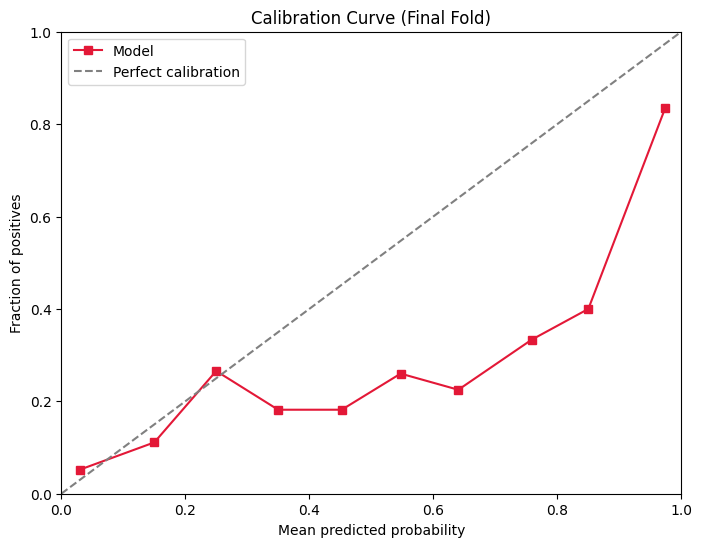


 Saved artifacts:
  /Users/ethanparks/Desktop/repos/nfl-crystal-ball/models/encoder.joblib
  /Users/ethanparks/Desktop/repos/nfl-crystal-ball/models/chiefs_wp_model.joblib
  /Users/ethanparks/Desktop/repos/nfl-crystal-ball/models/calibrator.joblib
  /Users/ethanparks/Desktop/repos/nfl-crystal-ball/models/feature_schema.json

 Quarter-Level Metrics Averaged Across Folds:
         Accuracy        F1  Precision_win  Recall_win  Precision_loss  \
Quarter                                                                  
1        0.611668  0.604485       0.643725    0.751080        0.553201   
2        0.731942  0.728457       0.737821    0.829622        0.709170   
3        0.796029  0.794963       0.806064    0.850328        0.768210   
4        0.899287  0.898034       0.896269    0.938064        0.905359   

         Recall_loss    F1_win   F1_loss  
Quarter                                   
1           0.425001  0.688672  0.473566  
2           0.591616  0.779430  0.642567  
3        

In [5]:
fold_results = []
all_quarter_metrics = []
all_test_preds = []

for i, test_years in enumerate(test_folds, start=1):
    test_years = list(test_years)
    train_years = [y for y in all_years if y not in test_years]

    print(f"\n Fold {i}")
    print(f"Train Years Used: {sorted(train_years)}")
    print(f"Test Years Used:  {sorted(test_years)}")

    train_df = df[df['season'].isin(train_years)].copy()
    test_df = df[df['season'].isin(test_years)].copy()
    fold_fteng = featEng(cat_cols=categorical_vars)
    train_df = fold_fteng.cat_transform(train_df)
    test_df = fold_fteng.transform_new(test_df)
    fold_df = pd.concat([train_df, test_df], ignore_index=True)

    clss = Classifiers()
    chiefs_xgb = clss.xgb(scale_pos_weight=1, **XGB_CFG)

    ttd = TTD(model_type='bin-xgb', model=chiefs_xgb)
    X_train, _, X_test, y_train, _, y_test = ttd.ttd_year_splits(
        fold_df,
        x_col=X_cols,
        y_col=Y_COL,
        time_col='season',
        train_seasons=train_years,
        dev_seasons=None,
        test_seasons=test_years,
    )

    chiefs_xgb.fit(X_train, y_train)

    _, X_cal, _, y_cal = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=TRAIN_CFG['random_seed']
    )
    y_cal_proba = chiefs_xgb.predict_proba(X_cal)[:, 1]
    calibrator = ProbabilityCalibrator(method='platt')
    calibrator.fit(y_cal, y_cal_proba)

    y_proba_raw = chiefs_xgb.predict_proba(X_test)[:, 1]
    y_proba = calibrator.calibrate(y_proba_raw)
    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    prec_win = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_win = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    prec_loss = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec_loss = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

    fold_results.append({
        'Fold': i,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Precision_win': prec_win,
        'Recall_win': rec_win,
        'Precision_loss': prec_loss,
        'Recall_loss': rec_loss,
        'brier_score_raw': calibrator.brier_score(y_test, y_proba_raw),
        'brier_score_calibrated': calibrator.brier_score(y_test, y_proba),
        'n_test_samples': len(y_test),
    })

    if i == n_folds:
        final_y_test = y_test
        final_y_proba_cal = y_proba
        final_calibrator = calibrator
        final_chiefs_xgb = chiefs_xgb
        final_X_test = X_test

    fold_test_df = test_df.copy().reset_index(drop=True)
    fold_test_df['y_true'] = y_test.values
    fold_test_df['y_pred'] = y_pred
    fold_test_df['y_proba'] = y_proba
    fold_test_df['quarter'] = fold_test_df['quarter'].astype(str)
    fold_test_df['confidence'] = abs(2 * fold_test_df['y_proba'] - 1)
    all_test_preds.append(fold_test_df)

    quarter_confidence = fold_test_df.groupby('quarter')['confidence'].median()
    print("Average Model Confidence by Quarter:")
    print(quarter_confidence)

    metrics_by_qtr = []
    for qtr, group in fold_test_df.groupby('quarter'):
        acc_q = accuracy_score(group['y_true'], group['y_pred'])
        overall_f1 = f1_score(group['y_true'], group['y_pred'], average='weighted')
        prec_win = precision_score(group['y_true'], group['y_pred'], pos_label=1, zero_division=0)
        rec_win = recall_score(group['y_true'], group['y_pred'], pos_label=1, zero_division=0)
        f1_win = f1_score(group['y_true'], group['y_pred'], pos_label=1, zero_division=0)
        prec_loss = precision_score(group['y_true'], group['y_pred'], pos_label=0, zero_division=0)
        rec_loss = recall_score(group['y_true'], group['y_pred'], pos_label=0, zero_division=0)
        f1_loss = f1_score(group['y_true'], group['y_pred'], pos_label=0, zero_division=0)

        metrics_by_qtr.append({
            'Fold': i,
            'Quarter': qtr,
            'Accuracy': acc_q,
            'F1': overall_f1,
            'Precision_win': prec_win,
            'Recall_win': rec_win,
            'Precision_loss': prec_loss,
            'Recall_loss': rec_loss,
            'F1_win': f1_win,
            'F1_loss': f1_loss,
            'n_test_samples': len(group),
        })

    all_quarter_metrics.append(pd.DataFrame(metrics_by_qtr))

# --- Persist encoder, CV results, and production model ---
final_fteng = featEng(cat_cols=categorical_vars)
df_encoded = final_fteng.cat_transform(df.copy())
final_fteng.save_encoder(str(MODELS_DIR / 'encoder.joblib'))

cv_results = pd.DataFrame(fold_results)
quarter_eval_df = pd.concat(all_quarter_metrics, ignore_index=True)
combined_df = pd.concat(all_test_preds, ignore_index=True)

cv_results.to_csv(OUTPUTS_DIR / 'cv_fold_results.csv', index=False)
quarter_eval_df.to_csv(OUTPUTS_DIR / 'quarter_eval_results.csv', index=False)

print("\n Cross-Validation Fold Results:")
print(cv_results[[
    'Fold', 'Accuracy', 'Precision', 'Recall', 'F1',
    'Precision_win', 'Recall_win', 'Precision_loss', 'Recall_loss'
]])

print("\n Average Performance Across Folds:")
print(cv_results[[
    'Accuracy', 'Precision', 'Recall', 'F1',
    'Precision_win', 'Recall_win', 'Precision_loss', 'Recall_loss'
]].mean())

print(f"\nRaw Brier Score: {cv_results['brier_score_raw'].mean():.3f}")
print(f"Calibrated Brier Score: {cv_results['brier_score_calibrated'].mean():.3f}")
print("Baseline (always predict 0.5): 0.250")

explainer = shap.TreeExplainer(final_chiefs_xgb)
shap_values = explainer.shap_values(final_X_test)
shap.summary_plot(
    shap_values,
    final_X_test,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'shap_feature_importance.png', dpi=150)
plt.close()

final_model = clss.xgb(scale_pos_weight=1, **XGB_CFG)
X_full = df_encoded[X_cols]
y_full = df_encoded[Y_COL]
final_model.fit(X_full, y_full)

_, X_cal, _, y_cal = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=TRAIN_CFG['random_seed']
)
y_cal_proba = final_model.predict_proba(X_cal)[:, 1]
production_calibrator = ProbabilityCalibrator(method='platt')
production_calibrator.fit(y_cal, y_cal_proba)

joblib.dump(final_model, MODELS_DIR / 'chiefs_wp_model.joblib')
joblib.dump(production_calibrator, MODELS_DIR / 'calibrator.joblib')
with open(MODELS_DIR / 'feature_schema.json', 'w') as f:
    json.dump(X_cols, f)

final_calibrator.plot_calibration_curve(
    final_y_test,
    final_y_proba_cal,
    title='Calibration Curve (Final Fold)',
    save_path=str(OUTPUTS_DIR / 'calibration_curve.png'),
)

print("\n Saved artifacts:")
print(f"  {MODELS_DIR / 'encoder.joblib'}")
print(f"  {MODELS_DIR / 'chiefs_wp_model.joblib'}")
print(f"  {MODELS_DIR / 'calibrator.joblib'}")
print(f"  {MODELS_DIR / 'feature_schema.json'}")

print("\n Quarter-Level Metrics Averaged Across Folds:")
print(quarter_eval_df.groupby('Quarter')[
    ['Accuracy', 'F1', 'Precision_win', 'Recall_win', 'Precision_loss', 'Recall_loss', 'F1_win', 'F1_loss']
].mean())


## 5. Statistical Tests — Confidence by Quarter

Friedman and Wilcoxon tests on median model confidence across quarters (paired by game).


In [11]:
q1 = combined_df[combined_df['quarter'] == '1']['confidence']
q2 = combined_df[combined_df['quarter'] == '2']['confidence']
q3 = combined_df[combined_df['quarter'] == '3']['confidence']
q4 = combined_df[combined_df['quarter'] == '4']['confidence']

print(f'Quarter 1 Median: {q1.median()}')
print(f'Quarter 2 Median: {q2.median()}')
print(f'Quarter 3 Median: {q3.median()}')
print(f'Quarter 4 Median: {q4.median()}')

combined_df['unq_game_id'] = combined_df.groupby(['season', 'opp_team', 'temperature_2m_max']).ngroup()
stat_df = combined_df.pivot_table(
    index='unq_game_id',
    columns='quarter',
    values='confidence',
    aggfunc='median',
).dropna()

Fr_stat, Fr_pval = friedmanchisquare(stat_df['1'], stat_df['2'], stat_df['3'], stat_df['4'])
print(f"Friedman test across quarters: Fr = {Fr_stat:.4f}, p = {Fr_pval:.4f}")

W_stat, W_pval = wilcoxon(stat_df['1'], stat_df['2'])
print(f"Wilcoxon signed-rank test Q1 vs Q2: W = {W_stat:.4f}, p = {W_pval:.4f}")


Quarter 1 Median: 0.8910658359527588
Quarter 2 Median: 0.9372161030769348
Quarter 3 Median: 0.9558523297309875
Quarter 4 Median: 0.9671347141265869
Friedman test across quarters: Fr = 162.9932, p = 0.0000
Wilcoxon signed-rank test Q1 vs Q2: W = 14339.0000, p = 0.0000


## 6. Visualizations

### Median Model Confidence by Quarter


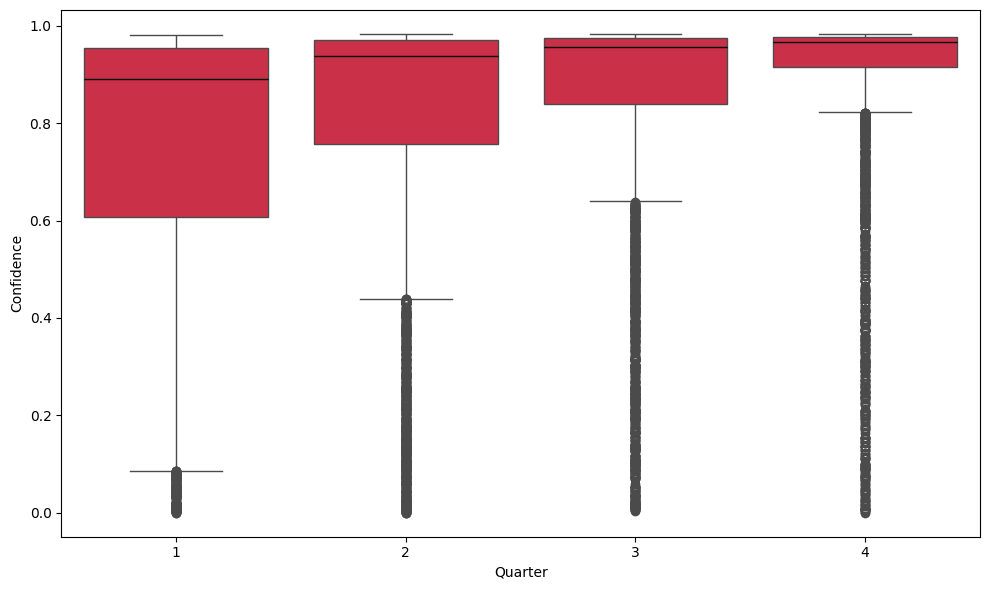

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='quarter',
    y='confidence',
    data=combined_df,
    order=['1', '2', '3', '4'],
    color='#E31837',
    medianprops=dict(color='black'),
)
plt.xlabel('Quarter')
plt.ylabel('Confidence')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confidence_by_quarter.png', dpi=150, bbox_inches='tight')
plt.show()


### Precision–Recall by Class (Each Fold)


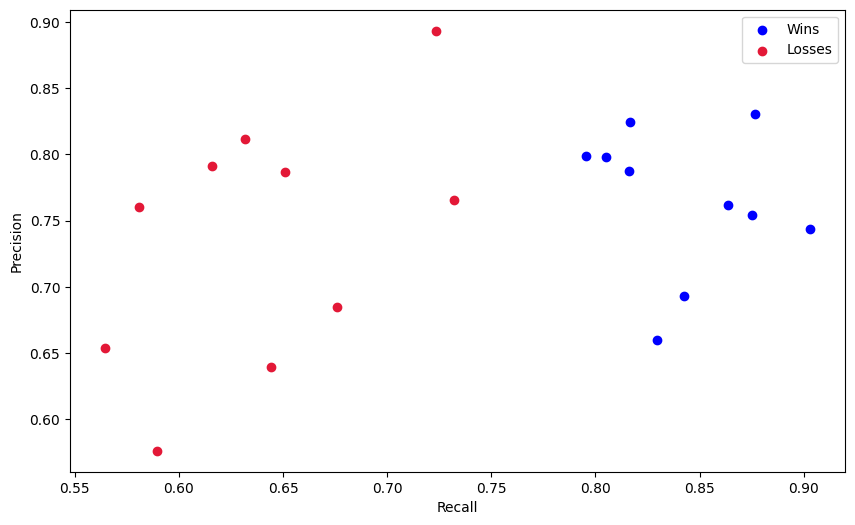

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(cv_results['Recall_win'], cv_results['Precision_win'], c='blue', label='Wins', alpha=1)
plt.scatter(cv_results['Recall_loss'], cv_results['Precision_loss'], c='#E31837', label='Losses', alpha=1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(False)
plt.legend()
plt.savefig(OUTPUTS_DIR / 'precision_recall_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


### Cross-Validation Metrics by Fold


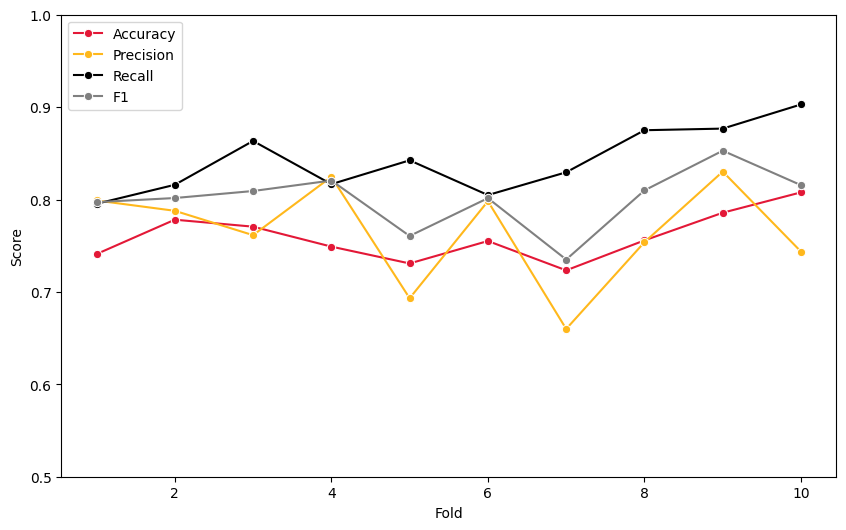

In [14]:
melted_df = cv_results.melt(id_vars='Fold', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'])
colorz = {
    'Accuracy': '#E31837',
    'Precision': '#FFB81C',
    'Recall': 'black',
    'F1': 'gray',
}

plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=melted_df, x='Fold', y='value', hue='variable', marker='o', palette=colorz)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.grid(False)
ax.legend(title=None)
plt.savefig(OUTPUTS_DIR / 'cv_metrics_by_fold.png', dpi=150, bbox_inches='tight')
plt.show()


### Quarter-Level Performance (Averaged Across Folds)


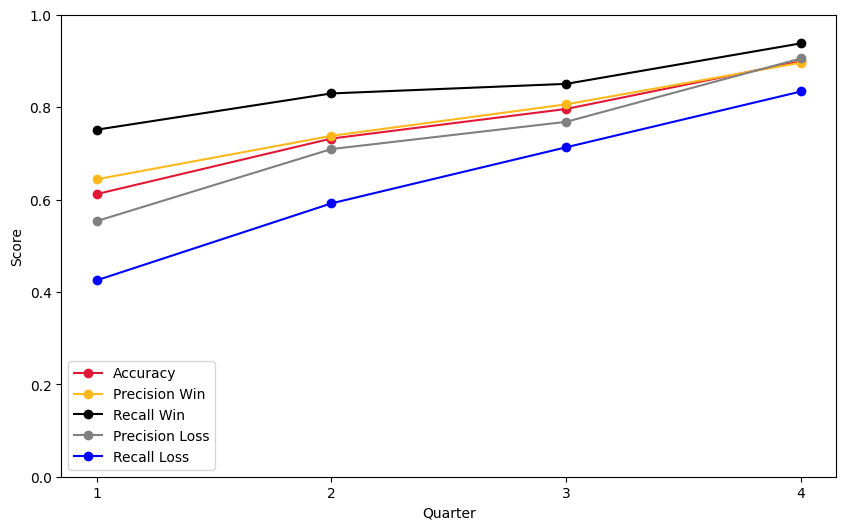

In [15]:
quarter_avg = quarter_eval_df.groupby('Quarter').mean().reset_index().rename(columns={
    'Accuracy': 'Accuracy',
    'Precision_win': 'Precision Win',
    'Recall_win': 'Recall Win',
    'Precision_loss': 'Precision Loss',
    'Recall_loss': 'Recall Loss',
})

metrics = ['Accuracy', 'Precision Win', 'Recall Win', 'Precision Loss', 'Recall Loss']
colorz = {
    'Accuracy': '#E31837',
    'Precision Win': '#FFB81C',
    'Recall Win': 'black',
    'Precision Loss': 'gray',
    'Recall Loss': 'blue',
}

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(
        quarter_avg['Quarter'],
        quarter_avg[metric],
        marker='o',
        label=metric,
        color=colorz[metric],
    )

plt.xlabel('Quarter')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(False)
plt.legend()
plt.savefig(OUTPUTS_DIR / 'quarter_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
